In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/archive/Mushrooms'

for item in os.listdir(INNER_PATH):
    path = os.path.join(INNER_PATH, item)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f'{item}: {count} images')

Boletus: 1073 images
Lactarius: 1578 images
Amanita: 750 images
Entoloma: 364 images
Hygrocybe: 316 images
Suillus: 311 images
Mushrooms: 0 images
Cortinarius: 836 images
Agaricus: 353 images
Russula: 1148 images


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Configuration ───────────────────────────────────────────
DATASET_PATH     = '/content/drive/MyDrive/archive/Mushrooms'
IMG_SIZE         = (128, 128)
BATCH_SIZE       = 32
EPOCHS           = 20
NUM_CLASSES      = 5
SEED             = 42

SELECTED_CLASSES = ['Agaricus', 'Amanita', 'Entoloma', 'Hygrocybe', 'Suillus']

print('TensorFlow version:', tf.__version__)
print('GPU available    :', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def data_loader(dataset_path=DATASET_PATH,
                img_size=IMG_SIZE,
                batch_size=BATCH_SIZE,
                val_split=0.15,
                test_split=0.15):
    """Loads images, splits into train/val/test, applies augmentation."""

    all_paths, all_labels = [], []

    for label, cls in enumerate(SELECTED_CLASSES):
        cls_dir = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_dir):
            print(f'[WARNING] folder not found: {cls_dir}')
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(cls_dir, fname))
                all_labels.append(label)

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    # Shuffle
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(all_paths))
    all_paths, all_labels = all_paths[idx], all_labels[idx]

    # Split
    n       = len(all_paths)
    n_test  = int(n * test_split)
    n_val   = int(n * val_split)

    test_paths,  test_labels  = all_paths[:n_test],                all_labels[:n_test]
    val_paths,   val_labels   = all_paths[n_test:n_test+n_val],    all_labels[n_test:n_test+n_val]
    train_paths, train_labels = all_paths[n_test+n_val:],          all_labels[n_test+n_val:]

    print(f'Total images : {n}')
    print(f'Train        : {len(train_paths)}')
    print(f'Validation   : {len(val_paths)}')
    print(f'Test         : {len(test_paths)}')

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = img / 255.0
        return img, tf.one_hot(label, NUM_CLASSES)

    def augment(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        return img, label

    def make_dataset(paths, labels, augment_data=False):
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        if augment_data:
            ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            ds = ds.shuffle(500, seed=SEED)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    train_gen = make_dataset(train_paths, train_labels, augment_data=True)
    val_gen   = make_dataset(val_paths,   val_labels)
    test_gen  = make_dataset(test_paths,  test_labels)

    return train_gen, val_gen, test_gen, SELECTED_CLASSES


train_gen, val_gen, test_gen, class_names = data_loader()
print('\nClasses:', class_names)

Total images : 2094
Train        : 1466
Validation   : 314
Test         : 314

Classes: ['Agaricus', 'Amanita', 'Entoloma', 'Hygrocybe', 'Suillus']


In [ ]:
def build_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Builds a CNN with 3 conv blocks + classifier head."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Mushroom_CNN')

    model.summary()
    return model


model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Mushroom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,213 (1.23 MB)

 Trainable params: 321,765 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
def trainer(model, train_gen, val_gen, epochs=EPOCHS):
    """Compiles and trains the CNN."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            'best_mushroom_model.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
    ]

    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )
    return history


history = trainer(model, train_gen, val_gen)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3264 - loss: 1.6519
Epoch 1: val_accuracy improved from None to 0.18790, saving model to best_mushroom_model.keras

Epoch 1: finished saving model to best_mushroom_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 311s 4s/step - accuracy: 0.3520 - loss: 1.5556 - val_accuracy: 0.1879 - val_loss: 1.6001 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4038 - loss: 1.4529
Epoch 2: val_accuracy improved from 0.18790 to 0.32166, saving model to best_mushroom_model.keras

Epoch 2: finished saving model to best_mushroom_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.4045 - loss: 1.4173 - val_accuracy: 0.3217 - val_loss: 1.5650 - learning_rate: 0.0010
Epoch 3/20
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4629 - loss: 1.3044
Epoch 3: val_accuracy did not improve from 0.32166
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.4509 - loss: 1.3218 - val_accuracy: 0.318

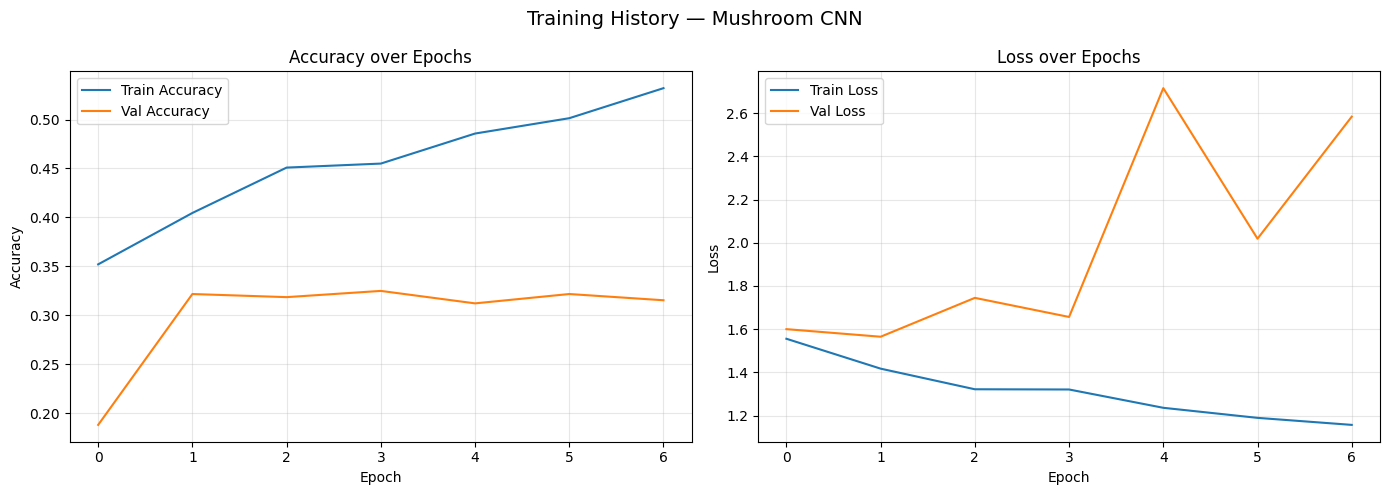

  Test Accuracy : 0.3503
  Precision     : 0.1856
  Recall        : 0.3503
  F1-Score      : 0.2030

Classification Report:

              precision    recall  f1-score   support

    Agaricus       0.00      0.00      0.00        54
     Amanita       0.35      0.97      0.52       108
    Entoloma       0.36      0.09      0.14        57
   Hygrocybe       0.00      0.00      0.00        43
     Suillus       0.00      0.00      0.00        52

    accuracy                           0.35       314
   macro avg       0.14      0.21      0.13       314
weighted avg       0.19      0.35      0.20       314



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


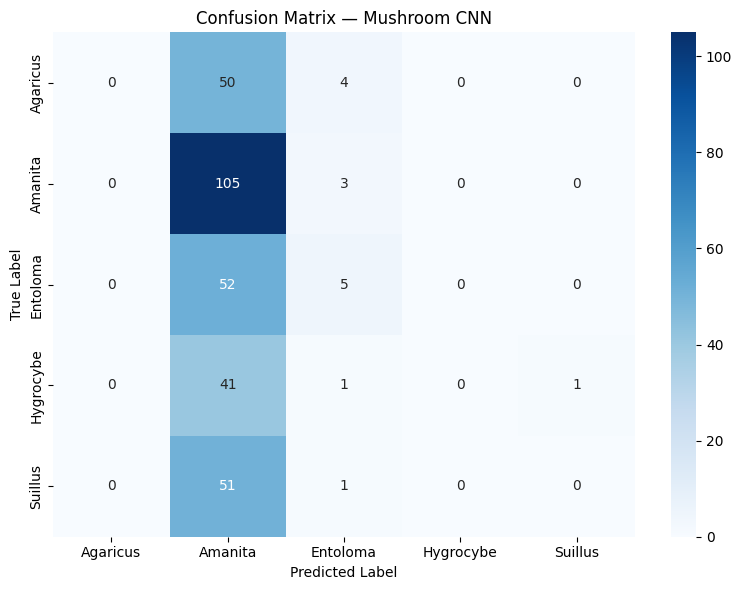

In [ ]:
def visualize_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History — Mushroom CNN', fontsize=14)

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, test_gen, class_names):
    y_true, y_pred = [], []
    for images, labels in test_gen:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=' * 50)
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  Precision     : {prec:.4f}')
    print(f'  Recall        : {rec:.4f}')
    print(f'  F1-Score      : {f1:.4f}')
    print('=' * 50)
    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix — Mushroom CNN')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    return y_true, y_pred


visualize_training(history)
y_true, y_pred = evaluate_model(model, test_gen, class_names)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Count samples per class in training set
train_labels_list = []
for _, labels in train_gen.unbatch():
    train_labels_list.append(np.argmax(labels.numpy()))
train_labels_list = np.array(train_labels_list)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_list
)
class_weights_dict = dict(enumerate(class_weights))
print('Class weights:', class_weights_dict)

Class weights: {0: np.float64(1.2267782426778242), 1: np.float64(0.5389705882352941), 2: np.float64(1.1498039215686275), 3: np.float64(1.3207207207207208), 4: np.float64(1.4233009708737865)}


In [ ]:
def build_transfer_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """MobileNetV2 pretrained on ImageNet + custom classifier head."""
    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # freeze pretrained layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Mushroom_TransferLearning')

    model.summary()
    return model


model_tl = build_transfer_model()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Mushroom_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint('best_mushroom_tl.keras',
                                     monitor='val_accuracy',
                                     save_best_only=True, verbose=1),
]

history_tl = model_tl.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weights_dict,    # ← fixes class imbalance
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3663 - loss: 1.8068
Epoch 1: val_accuracy improved from None to 0.66561, saving model to best_mushroom_tl.keras

Epoch 1: finished saving model to best_mushroom_tl.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 52s 632ms/step - accuracy: 0.4475 - loss: 1.4539 - val_accuracy: 0.6656 - val_loss: 0.9309 - learning_rate: 0.0010
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6347 - loss: 0.9621
Epoch 2: val_accuracy improved from 0.66561 to 0.70064, saving model to best_mushroom_tl.keras

Epoch 2: finished saving model to best_mushroom_tl.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.6460 - loss: 0.9396 - val_accuracy: 0.7006 - val_loss: 0.7777 - learning_rate: 0.0010
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6764 - loss: 0.8642
Epoch 3: val_accuracy improved from 0.70064 to 0.71975, saving model to best_mushroom_tl.keras

Epoch 3: finished saving model to best_mushroom_tl.keras
46

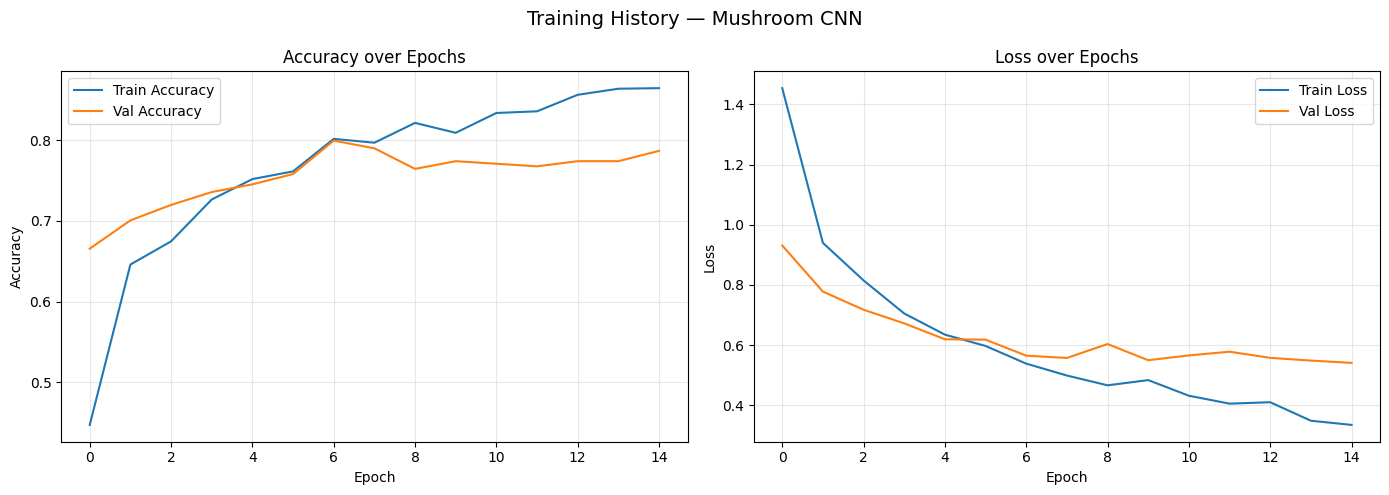

  Test Accuracy : 0.7739
  Precision     : 0.7732
  Recall        : 0.7739
  F1-Score      : 0.7716

Classification Report:

              precision    recall  f1-score   support

    Agaricus       0.64      0.54      0.59        54
     Amanita       0.79      0.82      0.81       108
    Entoloma       0.68      0.77      0.72        57
   Hygrocybe       0.89      0.93      0.91        43
     Suillus       0.87      0.79      0.83        52

    accuracy                           0.77       314
   macro avg       0.78      0.77      0.77       314
weighted avg       0.77      0.77      0.77       314



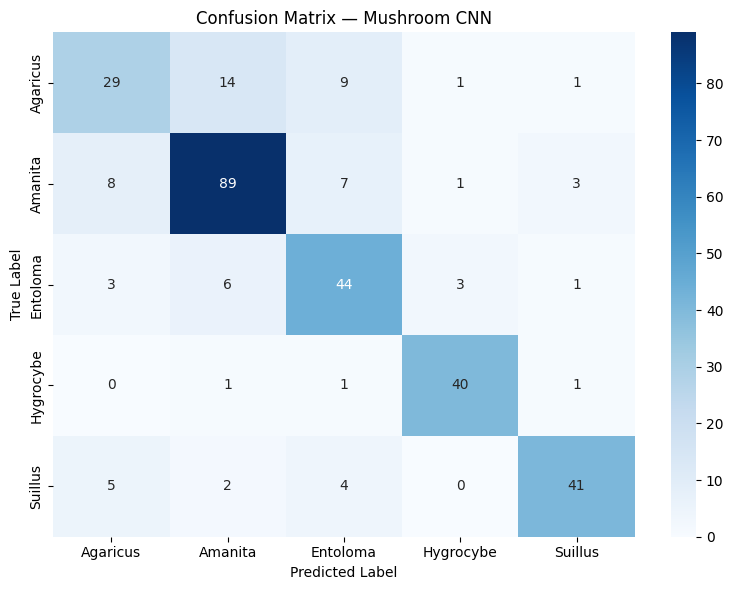

In [ ]:
visualize_training(history_tl)
y_true, y_pred = evaluate_model(model_tl, test_gen, class_names)